In [1]:
import sys
# Run this in a Jupyter cell — installs into the correct Python
!{sys.executable} -m pip install torch torchvision

  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 1.6 MB/s  0:00:48m0:00:0100:02
Using cached setuptools-81.0.0-py3-none-any.whl (1.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.5 MB/s  0:00:01 eta 0:00:01
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl (12 kB)
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/10 [sympy]
  

Week 1:

focused on ML workflow

high-level APIs

fast experimentation

Week 2:

focuses on neural network mechanics

manual training loops

understanding learning internally

PyTorch:

lower-level than sklearn

more verbose

far more educational

Main concept:

Deep learning is not magic — it is repeated mathematical optimization through gradients and 
weight updates

In [2]:
import torch

# Creating tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.zeros(3)
c = torch.ones(2, 3)       # 2 rows, 3 cols
d = torch.randn(3, 4)      # random normal, shape [3,4]

print(a)
print(a.shape)             # torch.Size([3])
print(a.dtype)             # float32 by default
print(d.shape)             # torch.Size([3, 4])

tensor([1., 2., 3.])
torch.Size([3])
torch.float32
torch.Size([3, 4])


In [4]:
# Operations — same as numpy
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

print(x + y)               # element-wise add
print(x * y)               # element-wise multiply
print(x @ y)               # dot product = 32.0
print(x.mean())
print(x.sum())

tensor([5., 7., 9.])
tensor([ 4., 10., 18.])
tensor(32.)
tensor(2.)
tensor(6.)


In [5]:
# Reshaping — critical skill
t = torch.arange(12, dtype=torch.float32)
print(t)                   # [0,1,2,...,11]
print(t.shape)             # [12]

t2 = t.reshape(3, 4)      # 3 rows, 4 cols
t3 = t.reshape(2, 6)
t4 = t.reshape(2, 2, 3)   # 3D tensor

print(t2)
print(t2.shape)            # torch.Size([3, 4])

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])
torch.Size([12])
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
torch.Size([3, 4])


In [6]:
# PyTorch ↔ numpy bridge
import numpy as np

arr = np.array([1.0, 2.0, 3.0])
tensor = torch.from_numpy(arr)          # numpy → tensor
back   = tensor.numpy()                 # tensor → numpy

print(type(tensor), tensor)
print(type(back), back)

<class 'torch.Tensor'> tensor([1., 2., 3.], dtype=torch.float64)
<class 'numpy.ndarray'> [1. 2. 3.]


Tensor:


core PyTorch data structure


similar to NumPy arrays


Important concepts:


shape


dimensions


tensor operations


reshaping


NumPy conversion


Key idea:
Deep learning = tensors + mathematical operations + gradients

In [7]:
import torch

# A weight — something we want to learn
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)           # input — fixed, not learned

# Forward pass: compute output and loss
y_pred = w * x                  # predicted output = 6.0
y_true = torch.tensor(9.0)      # what we wanted
loss   = (y_pred - y_true) ** 2 # squared error = 9.0

print("w:", w)
print("y_pred:", y_pred)
print("loss:", loss)

w: tensor(2., requires_grad=True)
y_pred: tensor(6., grad_fn=<MulBackward0>)
loss: tensor(9., grad_fn=<PowBackward0>)


# 🏀 Real-Life Analogy: Learning Basketball Shots

Imagine you are on a court learning how to shoot a basketball. This simple act perfectly mirrors how a neural network learns.

---

## 🛠️ The Core Components

* **The Weight ($w$)** — **Your shooting force.**
  * *Too weak* $\rightarrow$ The ball falls short.
  * *Too strong* $\rightarrow$ The ball overshoots.
  * **Concept:** The weight is your adjustable skill parameter.
* **The Input ($x$)** — **Distance from the basket.**
  * *Example:* You are standing $3\text{ meters}$ away.

---

## 🔄 The Trial (Forward Pass)

### 1. Prediction ($y_{pred}$)
You attempt the shot using your current internal formula: 

$$\text{Force } (w) \times \text{Distance } (x) = \text{Shot Distance } (y_{pred})$$

* If your current shooting force $w = 2$ and distance $x = 3$:
* Your shot reaches only **$6\text{ units}$**.

### 2. Actual Desired Output ($y_{true}$)
To actually make the basket, the ball needs to travel **$9\text{ units}$**. Your shot fails.

### 3. The Loss
The loss measures **"How bad was the mistake?"**
* **Large Loss** $\rightarrow$ A really bad shot.

---

## 🧠 The Important Part: Learning & Gradients

After missing, your brain naturally thinks: *"Oh, I need to throw harder next time."* 

That exact intuition is the **Gradient**. 
* The gradient tells you **which direction** to change your force (increase it).
* It tells you roughly **how much** to change it.

---

## 🤖 Enter PyTorch Autograd: The Automatic Coach

In a real shot, your brain isn't just calculating force. It manages millions of shooting parameters simultaneously:
* Wrist angle
* Jump height
* Ball spin
* Elbow position
* Release timing

Humans cannot manually calculate adjustments for all of these at once. **PyTorch Autograd acts as your automatic coach.** 

1. It tracks **all calculations** and **all mistakes**.
2. It automatically computes **which specific weights** caused the error.
3. It determines **how each individual weight** should change.

---

## 🔍 Why do we set `requires_grad=True`?

In training, some elements must adapt while others stay fixed.


| Variable | Represents | Should it learn? | `requires_grad` |
| :--- | :--- | :--- | :--- |
| **Weight ($w$)** | Shooting Force | **YES** (Must improve) | `True` |
| **Input ($x$)** | Basket Distance | **NO** (Fixed reality) | `False` |

> 💡 **Summary:** This is why only weights track gradients in a neural network.

---

## 🚀 Neural Network Learning in Plain English

Neural networks learn exactly like humans:
$$\text{Try} \rightarrow \text{Make Mistake} \rightarrow \text{Measure Mistake} \rightarrow \text{Adjust Slightly} \rightarrow \text{Try Again} \rightarrow \text{Improve Slowly}$$

### What Autograd Really Does
Autograd automatically answers one question: *"If the loss increased, which weights caused it, and how should they change?"* This is the entire foundation of deep learning.

### One-Line Intuition
> **Deep learning is basically automatic trial-and-error improvement using mathematics.**

### ⚠️ An Important Mental Model
Neural network training is **NOT** "AI magically thinking." It is simply **repeated tiny corrections after mistakes**, just like:
* Learning basketball
* Learning guitar
* Learning driving
* Learning pronunciation

The only difference is that neural networks use **gradients** to automate this correction process mathematically.


In [8]:
import torch

w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

# Forward pass
y_pred = w * x          # 6.0
y_true = torch.tensor(9.0)
loss   = (y_pred - y_true) ** 2  # (6-9)² = 9.0

# Backward pass — PyTorch computes dLoss/dw automatically
loss.backward()

print("Gradient dL/dw:", w.grad)   # should be -18.0

Gradient dL/dw: tensor(-18.)


MOST Important Deep Learning Loop

This repeats millions of times:

Forward pass
→ compute loss
→ backward pass
→ compute gradients
→ update weights
→ improve prediction

That is:

Neural network learning

Simple Mental Model

Gradient is basically:

“Advice for the weight”

Example:

| Gradient        | Meaning                  |
| --------------- | ------------------------ |
| negative        | increase weight          |
| positive        | decrease weight          |
| large magnitude | strong correction needed |
| near zero       | already close to optimal |


Quick Summary

loss.backward():

computes gradients automatically

w.grad:

tells how weight affects loss

Negative gradient:

increase weight

Positive gradient:

decrease weight

Main concept:

Neural networks learn because gradients tell weights how to adjust to reduce prediction error

In [10]:
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)
y_true = torch.tensor(9.0)
lr = 0.01  # learning rate

for step in range(100):
    # Forward
    y_pred = w * x
    loss   = (y_pred - y_true) ** 2

    # Backward
    loss.backward()

    # Update weight (no gradient tracking during update)
    with torch.no_grad():
        w -= lr * w.grad

    # Reset gradient — CRITICAL, gradients accumulate otherwise
    w.grad.zero_()

    if step % 10 == 0:
        print(f"Step {step:3d} | w={w.item():.4f} | loss={loss.item():.4f}")

Step   0 | w=2.1800 | loss=9.0000
Step  10 | w=2.8873 | loss=0.1700
Step  20 | w=2.9845 | loss=0.0032
Step  30 | w=2.9979 | loss=0.0001
Step  40 | w=2.9997 | loss=0.0000
Step  50 | w=3.0000 | loss=0.0000
Step  60 | w=3.0000 | loss=0.0000
Step  70 | w=3.0000 | loss=0.0000
Step  80 | w=3.0000 | loss=0.0000
Step  90 | w=3.0000 | loss=0.0000


Learned: w=1.951, b=0.140


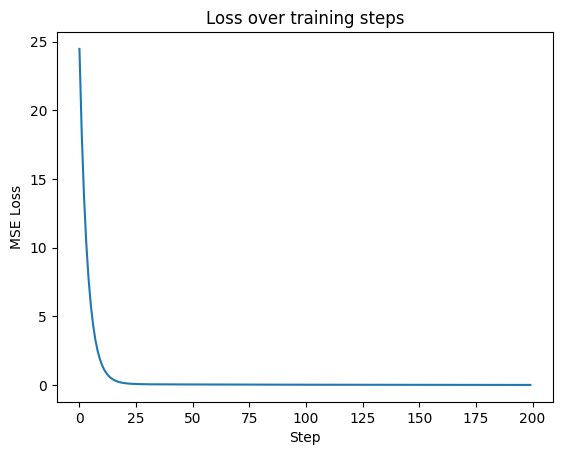

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# XOR-like toy data
X = torch.tensor([[0.0],[1.0],[2.0],[3.0],[4.0]])
y = torch.tensor([[0.0],[2.0],[4.0],[6.0],[8.0]])  # y = 2x

# Single neuron: y = w*x + b
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

losses = []
lr = 0.01

for step in range(200):
    y_pred = X * w + b          # forward
    loss   = ((y_pred - y) ** 2).mean()   # MSE loss

    loss.backward()             # backward

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    w.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

print(f"Learned: w={w.item():.3f}, b={b.item():.3f}")  # should be ~2.0, ~0.0
plt.plot(losses)
plt.title("Loss over training steps")
plt.xlabel("Step"); plt.ylabel("MSE Loss")
plt.show()

Quick Summary

Single neuron:

uses equation wx+b

predicts outputs

computes MSE loss

uses gradients to update w and b

Loss graph:

shows learning progress

Expected learning:

w → 2
b → 0

Main concept:

A neuron learns by repeatedly adjusting its weight and bias to reduce average prediction error across data points